In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
from helper import Autoencoder, load_data, get_embedding, format_data_into_experiment,load_params

In [2]:
# Settings for initial data
#[['OT-1'], ['A2', 'E1', 'G4', 'N4', 'Q4', 'T4', 'V4', 'null'], ['10pM', '1nM', '1uM'], ['12.0', '24.0', '30.0', '36.0', '4.0', '48.0', '60.0', '72.0']]

ignore_indexes=['Event','Replicate']

data_path = "../../initialSingleCellDf-channel-20220916-MW_018-001.h5"
data = pd.read_hdf(data_path, key="df")
data = data.loc[(data.index.get_level_values('CellType') == 'OT-1')]

strength_over_time_settings = {
    'plots_for':['CellType','Concentration'],
    'order_plots_by':[['OT-1'],['10uM', '1nM', '1pM']],
    'sort_lines_by':'Peptide',
    'sort_lines_by_order':['N4','A2', 'Q4', 'T4','V4', 'G4','E1','null']
}
trajectory_graph_settings = {
    'plots_for':['CellType','Peptide'],
    'order_plots_by':[['OT-1'],['N4','A2', 'Q4', 'T4','V4', 'G4','E1','null']],
    'sort_lines_by':'Concentration',
    'sort_lines_by_order':['10pM', '1nM', '1uM']
}

bar_graph_settings = {
    'color_by':'Peptide',
    'order_by':['N4','A2', 'Q4', 'T4','V4', 'G4','E1','null'],
    'secondary_order_by':'Concentration',
    'secondary_order':['10pM', '1nM', '1uM'],

}

cosine_similarity_settings = {
    'reference_experiment':{
        'CellType':'OT-1',
        'Concentration':'1uM',
        'Peptide':'null'
    },
    'plots_for':['CellType','Concentration'],
    'order_plots_by':[['OT-1'],['10pM', '1nM', '1uM']],
    'sort_lines_by':'Peptide',
    'sort_lines_by_order':['N4','A2', 'Q4', 'T4','V4', 'G4','E1','null']
}


In [3]:
# Settings for combined data
#[['OT-1'], ['hgp100', 'mgp100', 'null'], ['N4', 'Q4', 'V4', 'null'], ['0:1', '1:0', '1:1', '1:3', '1:6', '1:9', '3:1', '9:1'], ['24.0', '36.0', '48.0', '72.0']]

# ignore_indexes=['Event']

# data_path = "../../initialSingleCellDf-channel-20220926-MW_020.h5"
# data = pd.read_hdf(data_path, key="df")
# data = data.loc[(data.index.get_level_values('CellType') == 'OT-1')]#& (data.index.get_level_values('Ratio') == '0:1')

# strength_over_time_settings = {
#     'plots_for':['CellType','Ratio'],
#     'order_plots_by':[['OT-1'],['0:1', '1:9','1:6','1:3', '1:1', '3:1', '9:1','1:0']],
# }
# trajectory_graph_settings = {
#     'plots_for':['CellType','Antigen2','Antigen1'],
#     'order_plots_by':[['OT-1'],['N4', 'Q4','V4','null'],['hgp100', 'mgp100', 'null']]
# }

# bar_graph_settings = {
#     'color_by':'Antigen2',
#     'order_by':['N4', 'Q4','V4','null']
# }

In [4]:
#load params
model_inputs,group_size,batch_size,embedding_size,autoencoder_hidden_sizes,model_path = load_params()
group_size = 25
print("model_inputs:", model_inputs)
print("group_size:", group_size)
print("batch_size:", batch_size)
print("embedding_size:", embedding_size)
print("autoencoder_hidden_sizes:", autoencoder_hidden_sizes)
print("model_path:", model_path)

model_inputs: ['CD126', 'CD19', 'CD2', 'CD25', 'CD27', 'CD38', 'CD4', 'CD44', 'CD45', 'CD45RA', 'CD5', 'CD62L', 'CD86', 'CD8a', 'CX3CR1', 'CXCR6', 'FSC-A', 'Granzyme B', 'ICOS', 'IRF8', 'MHC-II', 'OX40', 'PD-L1', 'Proliferation', 'SSC-A', 'TBet']
group_size: 25
batch_size: 100
embedding_size: 2
autoencoder_hidden_sizes: [250, 200]
model_path: autoencoder_test.pt


In [5]:
dataset, index_order, data_index_names, data_columns, data_labels,missing_columns = load_data(data,model_inputs,ignore_indexes,group_size,transform='normalize')
print("Missing columns: ",missing_columns)
print("Data index names: ",data_index_names)
print("Index order: ",index_order)

Missing columns:  []
Data index names:  ['CellType' 'Peptide' 'Concentration' 'Time']
Index order:  [['OT-1'], ['A2', 'E1', 'G4', 'N4', 'Q4', 'T4', 'V4', 'null'], ['10pM', '1nM', '1uM'], ['12.0', '24.0', '30.0', '36.0', '4.0', '48.0', '60.0', '72.0']]


In [6]:
model = Autoencoder(len(model_inputs),autoencoder_hidden_sizes,embedding_size)
model.load_state_dict(torch.load(model_path))
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
model = model.to(device)
model

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=26, out_features=250, bias=True)
    (1): ReLU()
    (2): Linear(in_features=250, out_features=200, bias=True)
    (3): ReLU()
    (4): Linear(in_features=200, out_features=2, bias=False)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=200, bias=True)
    (1): ReLU()
    (2): Linear(in_features=200, out_features=250, bias=True)
    (3): ReLU()
    (4): Linear(in_features=250, out_features=26, bias=True)
  )
  (strength): Sequential(
    (0): Linear(in_features=2, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=1, bias=True)
  )
)

In [7]:
data_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)

In [8]:
embeddings,labels,markers,strengths = get_embedding(model,data_loader,device)
print(embeddings.shape)

(243852, 2)


In [9]:
output,experiment_label_order = format_data_into_experiment(embeddings,data_labels,data_index_names,strengths,ignore_columns=[])

In [38]:
def get_graph_data(plots_for,order_plots_by,output,sort_lines_by,sort_lines_by_order):
    graph_titles = [[]]
    for i in range(len(plots_for)):
        new_titles = []
        for title in graph_titles:
            for label in order_plots_by[i]:
                new_titles.append(title + [label])
        graph_titles = new_titles

    all_labels = np.array([exper['label'] for exper in output])
    plots_for_indexes = [list(data_index_names).index(plot_for) for plot_for in plots_for]
    all_labels = all_labels[:,plots_for_indexes]
    graph_titles = [title for title in graph_titles if np.any(np.all(all_labels == title,axis=1))]
    graph_experiments = []
    graph_labels= []
    for title in graph_titles:
        graph_experiments.append([exper for exper in output if np.all(exper['label'][plots_for_indexes] == title)])
        graph_labels_expr= []
        for exper in graph_experiments[-1]:
            graph_labels_expr.append(' '.join(exper['label'][[i for i in range(len(exper['label'])) if i not in plots_for_indexes]]))
        graph_labels.append(graph_labels_expr)
    # graph_experiments = [sorted(gexp,key=lambda x: sort_lines_by_order.index(x['label'][list(experiment_label_order).index(sort_lines_by)])) for gexp in graph_experiments]
    return graph_titles,graph_experiments,graph_labels

def get_graphs(title,output,plots_for,order_plots_by,get_plot,sort_lines_by,sort_lines_by_order):
    graph_titles,graph_experiments,graph_labels = get_graph_data(plots_for,order_plots_by,output,sort_lines_by,sort_lines_by_order)
    num_columns = min(4,len(graph_titles))
    num_rows = int((len(graph_titles)+num_columns-1)/num_columns)
    plt.figure(figsize=(5*num_columns,5*num_rows))
    # plt.suptitle(title+' for each ' + ' and '.join(plots_for))
    for i,title in enumerate(graph_titles):
        plt.subplot(num_rows,num_columns,i+1)
        ax = plt.gca()
        plt.title(' '.join(title[1:]))
        for j,exper in enumerate(graph_experiments[i]):
            get_plot(exper,graph_labels[i][j],ax)
        plt.legend()
    plt.show()
def get_markers_embedding(title,embeddings,markers,feature_names,strengths,times):
    # plt.figure(figsize=(20,15))
    # plt.suptitle(title)
    # for i in range(len(feature_names)):
    #     plt.subplot(5,6,i+1)
    #     plt.scatter(embeddings[:,0],embeddings[:,1],c=markers[:,i])
    #     plt.title(feature_names[i])
    #     plt.colorbar()
    min_embedding_x = -8
    max_embedding_x = 10
    # min_embedding_y = -7
    # max_embedding_y = 5
    # plt.subplot(5,6,len(feature_names)+1)
    # plt.scatter(embeddings[:,0],embeddings[:,1],c=strengths)
    # plt.xlim(min_embedding_x,max_embedding_x)
    # # plt.ylim(min_embedding_y,max_embedding_y)
    # plt.title("Strength")
    # plt.colorbar()
    # plt.subplot(5,6,len(feature_names)+2)
    # plt.scatter(embeddings[:,0],embeddings[:,1],c=times)
    # plt.xlim(min_embedding_x,max_embedding_x)
    # # plt.ylim(min_embedding_y,max_embedding_y)
    # plt.title("Time")
    # plt.colorbar()
    # plt.tight_layout()
    # plt.show()
    plt.figure(figsize=(9,2))
   
    # plt.suptitle('Latent Space Embedding')
    plt.subplot(1,4,1)
    plt.scatter(embeddings[:,0],embeddings[:,1],c=strengths)
    plt.xlim(min_embedding_x,max_embedding_x)
    # plt.ylim(min_embedding_y,max_embedding_y)
    plt.title("Predicted log(EC50)")
    plt.colorbar()
    plt.subplot(1,4,2)
    plt.scatter(embeddings[:,0],embeddings[:,1],c=times)
    plt.xlim(min_embedding_x,max_embedding_x)
    # plt.ylim(min_embedding_y,max_embedding_y)
    plt.title("Time")
    plt.colorbar()
    plt.tight_layout()
    plt.subplot(1,4,3)
    plt.scatter(embeddings[:,0],embeddings[:,1],c=markers[:,3])
    plt.xlim(min_embedding_x,max_embedding_x)
    # plt.ylim(min_embedding_y,max_embedding_y)
    plt.title(feature_names[3])
    plt.colorbar()
    plt.subplot(1,4,4)
    plt.scatter(embeddings[:,0],embeddings[:,1],c=markers[:,5])
    plt.xlim(min_embedding_x,max_embedding_x)
    # plt.ylim(min_embedding_y,max_embedding_y)
    plt.title(feature_names[5])
    plt.colorbar()
    plt.tight_layout()
    plt.show()

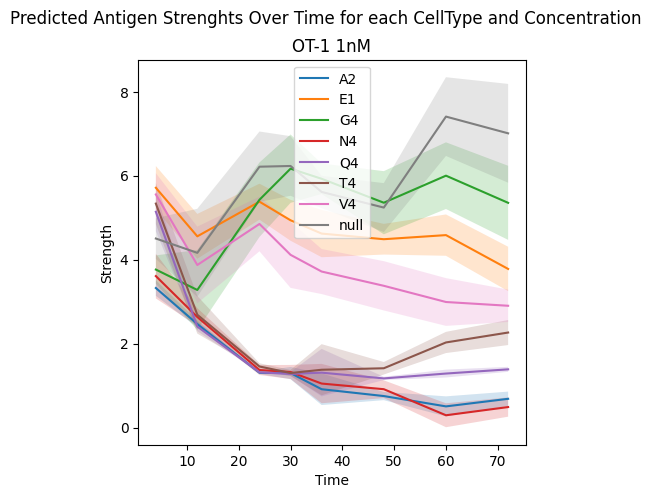

In [11]:
def get_strength_over_time_plot(exper,label,ax):
    plt.plot(exper['times'], exper['strengths'], label=label)
    plt.fill_between(exper['times'], exper['strengths']-exper['strengths_std'], exper['strengths']+exper['strengths_std'], alpha=0.2)
    plt.xlabel('Time')
    plt.ylabel('Strength')

get_graphs('Predicted Antigen Strenghts Over Time',output,strength_over_time_settings['plots_for'],strength_over_time_settings['order_plots_by'],get_strength_over_time_plot,strength_over_time_settings['sort_lines_by'],strength_over_time_settings['sort_lines_by_order'])

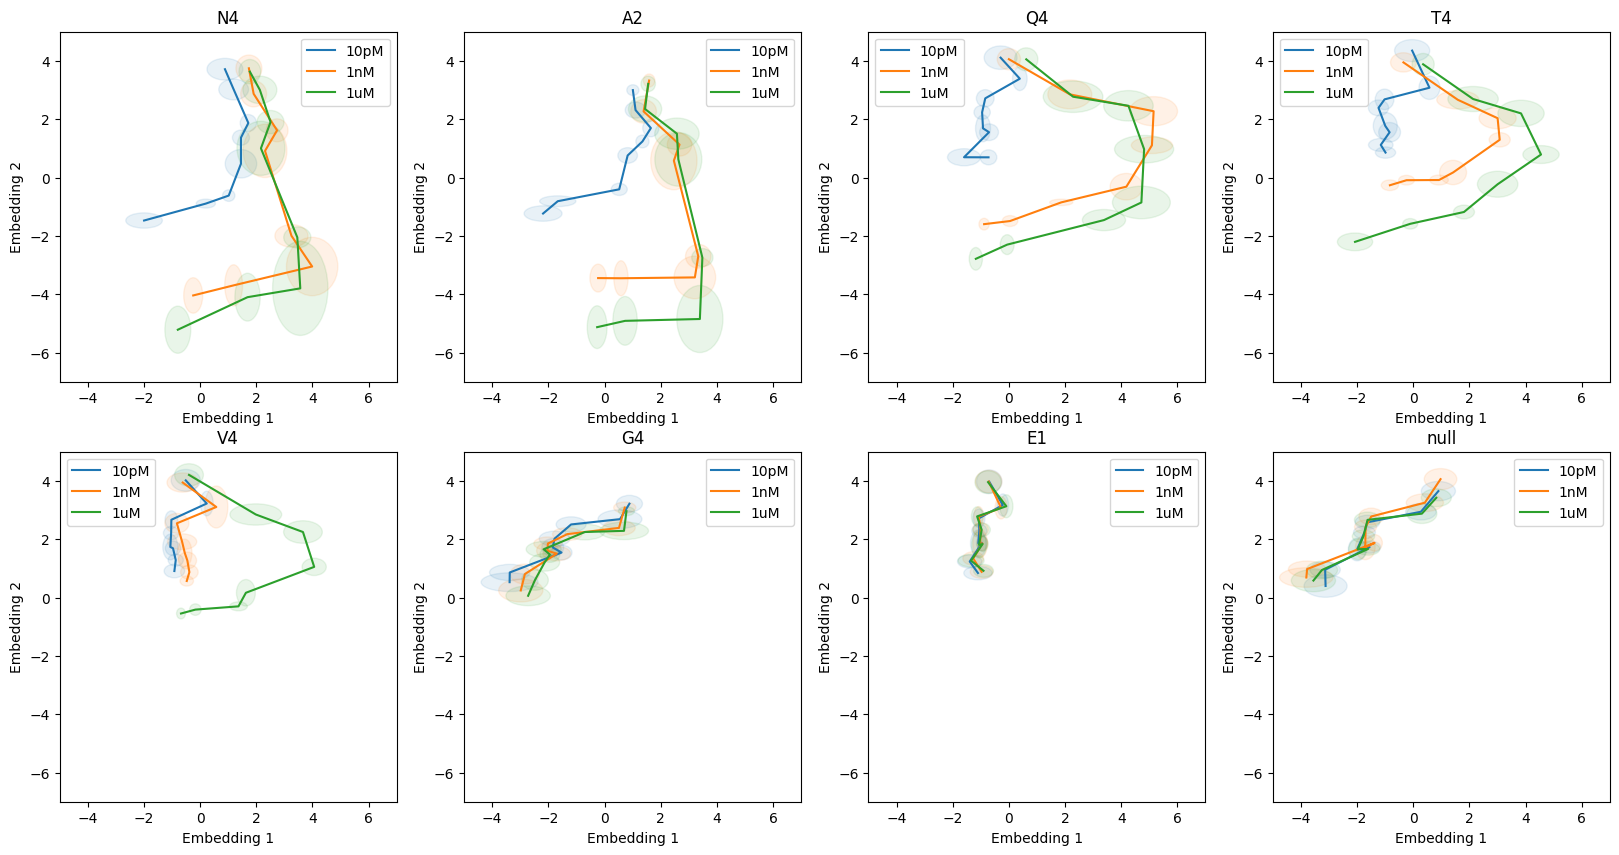

In [25]:
min_embedding_x = -5
max_embedding_x = 7
min_embedding_y = -7
max_embedding_y = 5
def get_plot(exper,label,ax):
    plt.plot(exper['embeddings'][:,0],exper['embeddings'][:,1],label=label)
    for i in range(len(exper['embeddings'])):
        ellipse = matplotlib.patches.Ellipse((exper['embeddings'][i,0], exper['embeddings'][i,1]), width=2*exper['embeddings_std'][i,0], height=2*exper['embeddings_std'][i,1], angle=0, color=ax.get_lines()[-1].get_color(), alpha=0.1)
        ax.add_patch(ellipse)
    plt.xlabel('Embedding 1')
    plt.ylabel('Embedding 2')
    plt.xlim([min_embedding_x,max_embedding_x])
    plt.ylim([min_embedding_y,max_embedding_y])
get_graphs('Trajectories',output,trajectory_graph_settings['plots_for'],trajectory_graph_settings['order_plots_by'],get_plot,trajectory_graph_settings['sort_lines_by'],trajectory_graph_settings['sort_lines_by_order'])

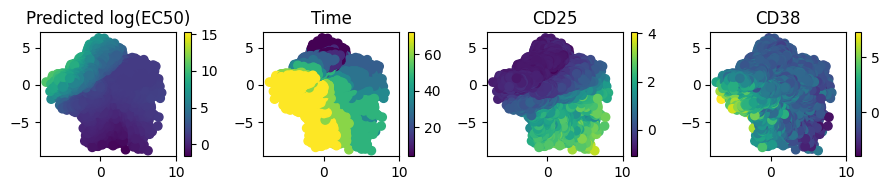

In [39]:
get_markers_embedding("Autoencoder",embeddings,markers,model_inputs,strengths,[float(d) for d in data_labels[:,list(data_index_names).index('Time')]])

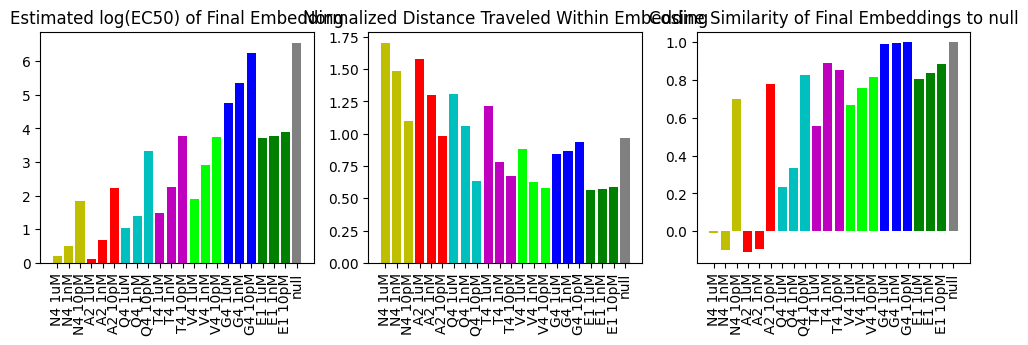

In [51]:

plt.figure(figsize=(15,3))
plt.subplot(1,3,1)
ax = plt.gca()

color_field = list(data_index_names).index(bar_graph_settings['color_by'])
secondary_field = list(data_index_names).index(bar_graph_settings['secondary_order_by'])
colors = ['r', 'g', 'b', 'y', 'c', 'm', 'lime', 'gray', 'orange', 'purple', 'pink', 'brown', 'olive', 'cyan', 'lightblue', 'lightgreen', 'lightgrey', 'lightcoral', 'lightpink', 'lightyellow', 'lightpurple', 'lightbrown', 'lightorange', 'lightcyan', 'lightolive']
bar_graph_settings = {
    'color_by':'Peptide',
    'order_by':['N4','A2', 'Q4', 'T4','V4', 'G4','E1','null'],
    'secondary_order_by':'Concentration',
    'secondary_order':['1uM', '1nM', '10pM'],
}

get_val = lambda x: bar_graph_settings['order_by'].index(x['label'][color_field])*len(bar_graph_settings['secondary_order']) + bar_graph_settings['secondary_order'].index(x['label'][secondary_field])

sorted_output = sorted(output, key=get_val)



for i,exper in enumerate(sorted_output[:-2]):
    label = ' '.join(exper['label'][1:])
    if exper['label'][1] == 'null':
        label = 'null'
    color_index = index_order[color_field].index(exper['label'][color_field])
    # color = get_experiment_color(experiment['label'],data_index_names)
    # if i %3 == 0:
    #     ax.bar(exper['label'][1]+' log(EC50)', known_strengths[exper['label'][1]], label=exper['label'][1], color=colors[color_index])
    ax.bar(label, exper['strengths'][-1], label=label, color=colors[color_index])#yerr=exper['strengths_std'][-1]
    
plt.xticks(rotation=90)
plt.title("Estimated log(EC50) of Final Embedding")


plt.subplot(1,3,2)
ax = plt.gca()

color_field = list(data_index_names).index(bar_graph_settings['color_by'])
colors = ['r', 'g', 'b', 'y', 'c', 'm', 'lime', 'gray', 'orange', 'purple', 'pink', 'brown', 'olive', 'cyan', 'lightblue', 'lightgreen', 'lightgrey', 'lightcoral', 'lightpink', 'lightyellow', 'lightpurple', 'lightbrown', 'lightorange', 'lightcyan', 'lightolive']
# sorted_output = sorted(output, key=lambda x: bar_graph_settings['order_by'].index(x['label'][color_field]))

reference = sorted_output[-3]['embeddings'][-1]
reference_std = sorted_output[-3]['embeddings_std'][-1]
reference_distance = np.linalg.norm(reference-sorted_output[-1]['embeddings'][0])
for exper in sorted_output[:-2]:
    label = ' '.join(exper['label'][1:])
    if exper['label'][1] == 'null':
        label = 'null'
    color_index = index_order[color_field].index(exper['label'][color_field])
    starting_point = exper['embeddings'][0]
    latest_point = exper['embeddings'][-1]
    distance = np.linalg.norm(latest_point-starting_point)
    # color = get_experiment_color(experiment['label'],data_index_names)
    ax.bar(label, distance/reference_distance, label=label, color=colors[color_index])
    plt.xticks(rotation=90)
plt.title("Normalized Distance Traveled Within Embedding")

plt.subplot(1,3,3)
ax = plt.gca()

color_field = list(data_index_names).index(bar_graph_settings['color_by'])
colors = ['r', 'g', 'b', 'y', 'c', 'm', 'lime', 'gray', 'orange', 'purple', 'pink', 'brown', 'olive', 'cyan', 'lightblue', 'lightgreen', 'lightgrey', 'lightcoral', 'lightpink', 'lightyellow', 'lightpurple', 'lightbrown', 'lightorange', 'lightcyan', 'lightolive']
# sorted_output = sorted(output, key=lambda x: bar_graph_settings['order_by'].index(x['label'][color_field]))

reference = sorted_output[-3]['embeddings'][-1]
reference_std = sorted_output[-3]['embeddings_std'][-1]

for exper in sorted_output[:-2]:
    label = ' '.join(exper['label'][1:])
    if exper['label'][1] == 'null':
        label = 'null'
    color_index = index_order[color_field].index(exper['label'][color_field])
    latest_point = exper['embeddings'][-1]
    variance_latest_point = exper['embeddings_std'][-1]
    
    cosine_similarity = np.dot(reference,latest_point)/(np.linalg.norm(reference)*np.linalg.norm(latest_point))
    cosine_similarity_variance = (np.dot(reference+reference_std,latest_point+variance_latest_point)/(np.linalg.norm(reference+reference_std)*np.linalg.norm(latest_point+variance_latest_point)) - cosine_similarity)/2
    # color = get_experiment_color(experiment['label'],data_index_names)
    ax.bar(label, cosine_similarity, label=label, color=colors[color_index])
    plt.xticks(rotation=90)
plt.title("Cosine Similarity of Final Embeddings to " + sorted_output[-1]['label'][1])


plt.show()


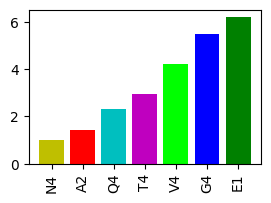

In [15]:
known_strengths = {'null':10,'N4': 0.0, 'Q4': 1.3340727612197436, 'Q7': 2.428134794028789, 'T4': 1.9599578912997808, 'V4': 3.2307473950102388, 'G4': 4.514668716435611, 'E1': 5.21564553829087, 'A2': 0.43209185328878835, 'Y3': 0.8603530802315512}
strength_order = ['N4','A2', 'Q4', 'T4','V4', 'G4','E1']
colors = ['y','r','c','m', 'lime', 'b', 'g','y', 'c', 'm', 'lime', 'gray', 'orange', 'purple', 'pink', 'brown', 'olive', 'cyan', 'lightblue', 'lightgreen', 'lightgrey', 'lightcoral', 'lightpink', 'lightyellow', 'lightpurple', 'lightbrown', 'lightorange', 'lightcyan', 'lightolive']
#bar graph of known_strengths for each strength_order
fig, ax = plt.subplots(figsize=(3,2))  # Set the figsize to (12, 6) for a wider plot
for i,strength in enumerate(strength_order):
    ax.bar(strength, known_strengths[strength]+1, label=strength, color=colors[i])
plt.xticks(rotation=90)
# plt.title("Known log(EC50)")
plt.show()



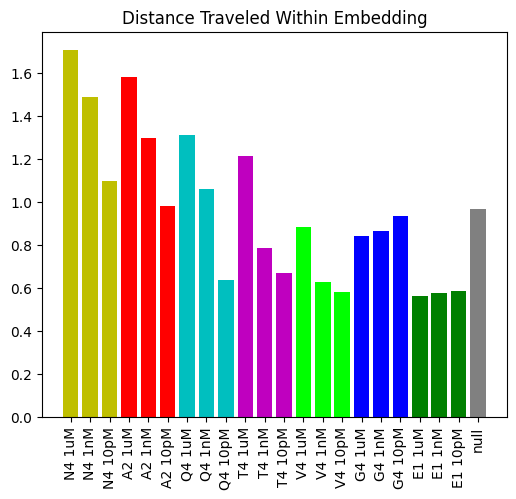

In [16]:
#Distance from beginning to end


fig, ax = plt.subplots(figsize=(int(len(output)/4), 5))  # Set the figsize to (12, 6) for a wider plot

color_field = list(data_index_names).index(bar_graph_settings['color_by'])
colors = ['r', 'g', 'b', 'y', 'c', 'm', 'lime', 'gray', 'orange', 'purple', 'pink', 'brown', 'olive', 'cyan', 'lightblue', 'lightgreen', 'lightgrey', 'lightcoral', 'lightpink', 'lightyellow', 'lightpurple', 'lightbrown', 'lightorange', 'lightcyan', 'lightolive']
# sorted_output = sorted(output, key=lambda x: bar_graph_settings['order_by'].index(x['label'][color_field]))

reference = sorted_output[-3]['embeddings'][-1]
reference_std = sorted_output[-3]['embeddings_std'][-1]
reference_distance = np.linalg.norm(reference-sorted_output[-1]['embeddings'][0])
for exper in sorted_output[:-2]:
    label = ' '.join(exper['label'][1:])
    if exper['label'][1] == 'null':
        label = 'null'
    color_index = index_order[color_field].index(exper['label'][color_field])
    starting_point = exper['embeddings'][0]
    latest_point = exper['embeddings'][-1]
    distance = np.linalg.norm(latest_point-starting_point)
    # color = get_experiment_color(experiment['label'],data_index_names)
    ax.bar(label, distance/reference_distance, label=label, color=colors[color_index])
    plt.xticks(rotation=90)
plt.title("Distance Traveled Within Embedding")
plt.show()


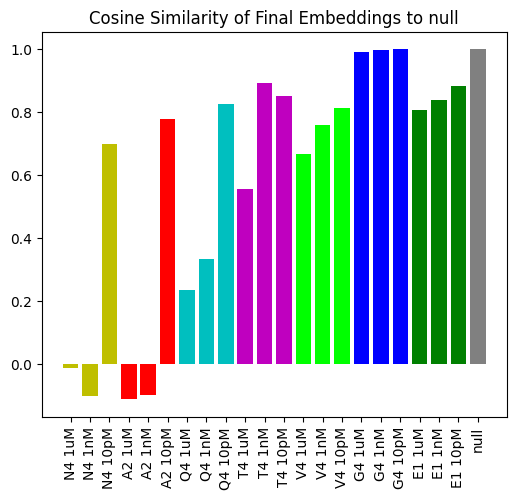

In [17]:

fig, ax = plt.subplots(figsize=(int(len(output)/4), 5))  # Set the figsize to (12, 6) for a wider plot

color_field = list(data_index_names).index(bar_graph_settings['color_by'])
colors = ['r', 'g', 'b', 'y', 'c', 'm', 'lime', 'gray', 'orange', 'purple', 'pink', 'brown', 'olive', 'cyan', 'lightblue', 'lightgreen', 'lightgrey', 'lightcoral', 'lightpink', 'lightyellow', 'lightpurple', 'lightbrown', 'lightorange', 'lightcyan', 'lightolive']
# sorted_output = sorted(output, key=lambda x: bar_graph_settings['order_by'].index(x['label'][color_field]))

reference = sorted_output[-3]['embeddings'][-1]
reference_std = sorted_output[-3]['embeddings_std'][-1]

for exper in sorted_output[:-2]:
    label = ' '.join(exper['label'][1:])
    if exper['label'][1] == 'null':
        label = 'null'
    color_index = index_order[color_field].index(exper['label'][color_field])
    latest_point = exper['embeddings'][-1]
    variance_latest_point = exper['embeddings_std'][-1]
    
    cosine_similarity = np.dot(reference,latest_point)/(np.linalg.norm(reference)*np.linalg.norm(latest_point))
    cosine_similarity_variance = (np.dot(reference+reference_std,latest_point+variance_latest_point)/(np.linalg.norm(reference+reference_std)*np.linalg.norm(latest_point+variance_latest_point)) - cosine_similarity)/2
    # color = get_experiment_color(experiment['label'],data_index_names)
    ax.bar(label, cosine_similarity, label=label, color=colors[color_index])
    plt.xticks(rotation=90)
plt.title("Cosine Similarity of Final Embeddings to " + sorted_output[-1]['label'][1])
plt.show()


In [18]:
#cosine over time wrt last experiment




def get_cosine_over_time_plot(exper,label,ax):
    plt.plot(exper['times'], exper['cosine_similarities'], label=label)
    plt.xlabel('Time')
    plt.ylabel('Cosine Similiarity')

cosine_similarity_settings = {
    'reference_experiment':{
        'CellType':'OT-1',
        'Concentration':'1uM',
        'Peptide':'null'
    },
    'plots_for':['CellType','Concentration'],
    'order_plots_by':[['OT-1'],['10pM', '1nM', '1uM']],
}


# print(output[0])
reference_experiments = []
for exper in output:
    matched = True
    for i,key in enumerate(experiment_label_order):
        if exper['label'][i] != cosine_similarity_settings['reference_experiment'][key]:
            matched = False
            break
    if matched:
        reference_experiments.append(exper)


# reference_experiments = [exper for exper in output if np.all([exper['label'][list(cosine_similarity_settings['reference_experiment'].keys()).index(key)] == value for key,value in cosine_similarity_settings['reference_experiment'].items()])]
print(len(reference_experiments))

reference_experiment = reference_experiments[0]

output_with_cosine = []
for exper in output:
    cosine_similarities = []
    for i in range(len(exper['embeddings'])):
        cosine_similarity = np.dot(reference_experiment['embeddings'][i],exper['embeddings'][i])/(np.linalg.norm(reference_experiment['embeddings'][i])*np.linalg.norm(exper['embeddings'][i]))
        cosine_similarities.append(cosine_similarity)
    output_with_cosine.append({'label':exper['label'],'times':exper['times'],'cosine_similarities':cosine_similarities})

get_graphs('Cosine Similarity Over Time',output_with_cosine,cosine_similarity_settings['plots_for'],cosine_similarity_settings['order_plots_by'],get_cosine_over_time_plot,cosine_similarity_settings['sort_lines_by'],cosine_similarity_settings['sort_lines_by_order'])


# output_with_cosine = []
# for exper in output:
    

# get_graphs('Predicted Antigen Strenghts Over Time',output,strength_over_time_settings['plots_for'],strength_over_time_settings['order_plots_by'],get_cosine_over_time_plot)



1


KeyError: 'sort_lines_by'